# XGBOOST

In [ ]:
#XGBoost (With SHAP to explain)
import shap
import xgboost as xgb
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [ ]:
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

In [ ]:
#Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [9]:
#Train XGBoost regressor
model = xgb.XGBRegressor().fit(X_train, y_train)

In [12]:
#Create SHAP explainer using training data as background
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap_values

 96%|=================== | 4975/5160 [00:16<00:00]       

.values =
array([[-0.34139812,  0.01441859, -0.11711825, ..., -0.23867892,
        -0.71913598, -0.12722322],
       [-0.34306768,  0.02107678, -0.10352989, ..., -0.083174  ,
        -0.7462329 , -0.02956519],
       [-0.0031419 ,  0.44144747, -0.11851477, ...,  0.93021113,
        -0.1010298 ,  1.91760576],
       ...,
       [-0.27975585,  0.01199092, -0.12051275, ..., -0.33444756,
         0.55391432, -0.65700765],
       [ 0.85075922, -0.01526783,  0.37782073, ..., -0.00958925,
        -1.04848958,  0.54825129],
       [ 0.97996681,  0.08026342, -0.00502129, ...,  0.1765228 ,
         0.90057549,  0.26106928]])

.base_values =
array([2.09828649, 2.09828649, 2.09828649, ..., 2.09828649, 2.09828649,
       2.09828649])

.data =
array([[   1.6812    ,   25.        ,    4.19220056, ...,    3.87743733,
          36.06      , -119.01      ],
       [   2.5313    ,   30.        ,    5.03938356, ...,    2.67979452,
          35.14      , -119.46      ],
       [   3.4801    ,   52.        

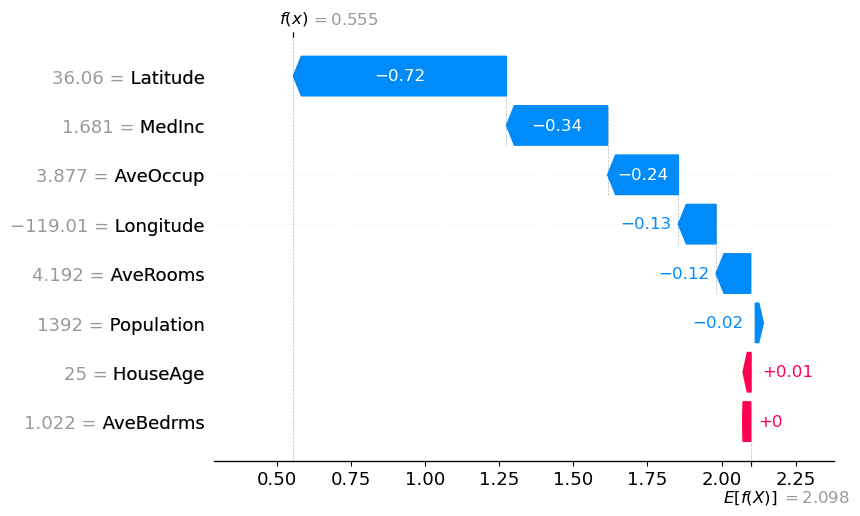

In [6]:
#Visualize a single prediction 
shap.plots.waterfall(shap_values[0])

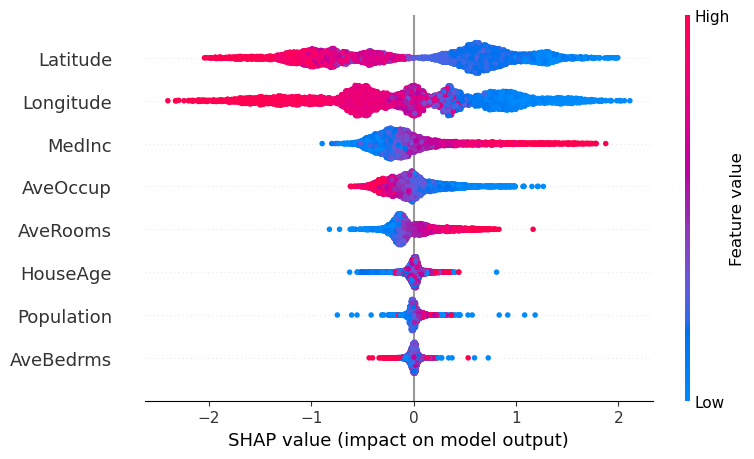

In [4]:
#Global feature importance summary
shap.summary_plot(shap_values, X_test)